### Овсянникова Майя группа 241, 16.02.2026

### Условие задачи
1. Построить столбчатую и круговую диаграмму для категориальных атрибутов набора данных
2. Построить остальные графики

### Теория

Я загрузила данные, затем выделила категориальные и метрические переменные и для каждого вида с помощью инструментов `matplotlib` построила 2 вида графиков.

### Документация

Используемые библиотеки:
- pandas – основная библиотека для работы с табличными данными
- matplotlib – библиотека для построения множества видов графиков и визуализации данных

Методы pandas:
- `.read_csv()` – загрузка данных из csv-файла
- `.select_dtypes()` – выбор столбцов по типу данных (у нас для выделения категориальных и метрических признаков)
- `.columns.tolist()` – преобразование названий столбцов в список
- `.value_counts()` – подсчет количества уникальных значений в столбце
- `.dropna()` – удаление пропущенных значений из данных
- `.mean()` – вычисление среднего арифметического
- `.median()` – вычисление медианы
- `.skew()` – вычисление коэффициента асимметрии (skewness)
- `.kurtosis()` – вычисление коэффициента эксцесса (kurtosis)
- `.quantile()` – вычисление заданного квантиля (например, 0.25 или 0.75)

Методы matplotlib:
- `.subplots()` – создание фигуры с несколькими сабплотами (осями) для размещения графиков.
- `.tight_layout()` – автоматическая настройка отступов между графиками для более компактного и аккуратного отображения
- `.show()` – отображение созданного графика
- `.bar()` – построение столбчатой диаграммы
- `.pie()` – построение круговой диаграммы
- `.hist()` – построение гистограммы
- `.boxplot()` – построение ящика с усами
- `.axhline()` – добавление горизонтальной линии на график
- `.set_ylim()` – установка лимитов для оси Y
- `.set_title()` – установка заголовка графика
- `.set_ylabel()` – установка подписи для оси Y
- `.set_xticks()` / `.set_xticklabels()` – настройка позиций и подписей делений на оси X
- `.legend()` – отображение легенды на графике
- `.grid()` – включение или отключение сетки
- `.text()` – добавление текстовой аннотации в заданные координаты графика (в координатах осей ax.transAxes или данных)

Дополнительные инструменты:
- `bar.get_height()` – получение высоты столбца для последующей аннотации
- `bar.get_x()` – получение координаты X столбца для последующей аннотации
- `bar.get_width()` – получение ширины столбца для последующей аннотации
- `wedges` – объекты, возвращаемые `.pie()`, для доступа к свойствам секторов диаграммы (например, `set_edgecolor`).
- `texts` / `autotexts` – объекты, возвращаемые `.pie()`, для доступа к текстовым меткам

### Решение

#### Загрузка данных

In [22]:
import pandas as pd

df = pd.read_csv('student_lifestyle_dataset.csv')

df.head(5)

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,Stress_Level,Gender,Grades
0,1,6.9,3.8,8.7,2.8,1.8,Moderate,Male,7.48
1,2,5.3,3.5,8.0,4.2,3.0,Low,Female,6.88
2,3,5.1,3.9,9.2,1.2,4.6,Low,Male,6.68
3,4,6.5,2.1,7.2,1.7,6.5,Moderate,Male,7.20
4,5,8.1,0.6,6.5,2.2,6.6,High,Male,8.78


#### 1. Построение графиков для категориальных атрибутов

##### Определение неметрических атрибутов набора данных

In [23]:
categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(categorical_columns)

['Stress_Level', 'Gender']


##### Столбчатая диаграмма

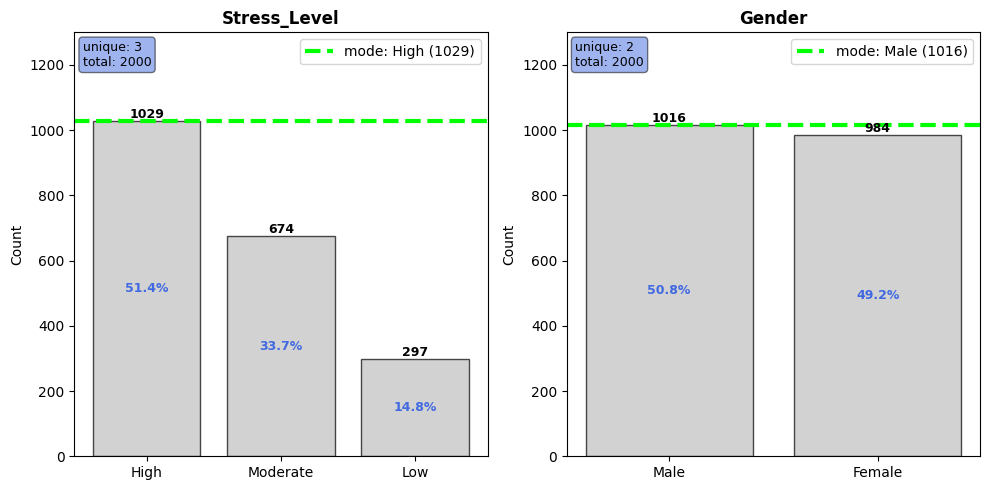

In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for i, col in enumerate(categorical_columns):
    ax = axes[i]
    
    value_counts = df[col].value_counts()
    categories = value_counts.index
    counts = value_counts.values
    
    bars = ax.bar(categories, counts, color='silver', edgecolor='black', alpha=0.7)
    
    mode_value = value_counts.index[0]
    mode_count = value_counts.iloc[0]

    ax.axhline(y=mode_count, color='lime', linestyle='--', linewidth=3, label=f'mode: {mode_value} ({mode_count})')
    
    ax.set_ylim(top=1300)
    ax.set_title(f'{col}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')
    ax.grid(False)
    ax.legend(fontsize=10)
    
    stats_text = f'unique: {len(categories)}\ntotal: {len(df[col])}'
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=9, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='royalblue', alpha=0.5))
    
    total = len(df[col])
    for bar in bars:
        height = bar.get_height()
        percentage = (height / total) * 100
        ax.text(bar.get_x() + bar.get_width()/2., height/2, f'{percentage:.1f}%', ha='center', va='center', fontsize=9, fontweight='bold', color='royalblue')
        ax.text(bar.get_x() + bar.get_width()/2., height, f'{int(height)}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

##### Круговая диаграмма

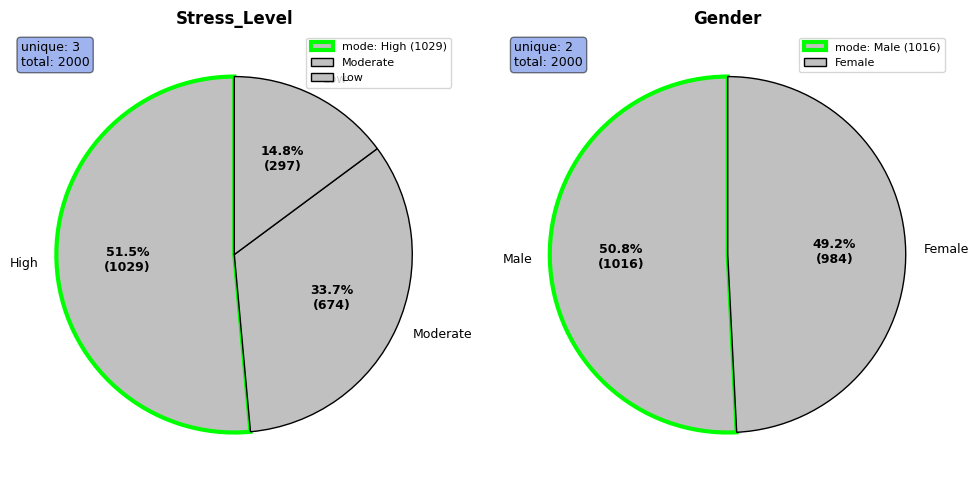

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for i, col in enumerate(categorical_columns):
    ax = axes[i]
    
    value_counts = df[col].value_counts()
    categories = value_counts.index
    counts = value_counts.values
    total = len(df[col])
    
    wedges, texts, autotexts = ax.pie(counts, labels=categories, autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*total)})',
                                       colors=['silver'] * len(counts), startangle=90, textprops={'fontsize': 9}, wedgeprops={'edgecolor': 'black', 'linewidth': 1})
    
    wedges[0].set_edgecolor('lime')
    wedges[0].set_linewidth(3)

    mode_value = value_counts.index[0]
    mode_count = value_counts.iloc[0]
    wedges[0].set_label(f'mode: {mode_value} ({mode_count})')
    
    for autotext in autotexts:
        autotext.set_color('black')
        autotext.set_fontweight('bold')
    
    ax.set_title(f'{col}', fontsize=12, fontweight='bold')
    
    stats_text = f'unique: {len(categories)}\ntotal: {total}'
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=9, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='royalblue', alpha=0.5))
    
    if wedges[0].get_label():
        ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

#### 1. Построение графиков для метрических атрибутов

##### Определение метрических атрибутов набора данных

In [26]:
metric_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(metric_columns)

['Student_ID', 'Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day', 'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day', 'Physical_Activity_Hours_Per_Day', 'Grades']


Только следует убрать `Student_ID`, поскольку это идентификатор, а не метрическая переменная

In [27]:
metric_columns.remove('Student_ID')
print(metric_columns)

['Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day', 'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day', 'Physical_Activity_Hours_Per_Day', 'Grades']


##### Построим простые гистограммы для метрических данных

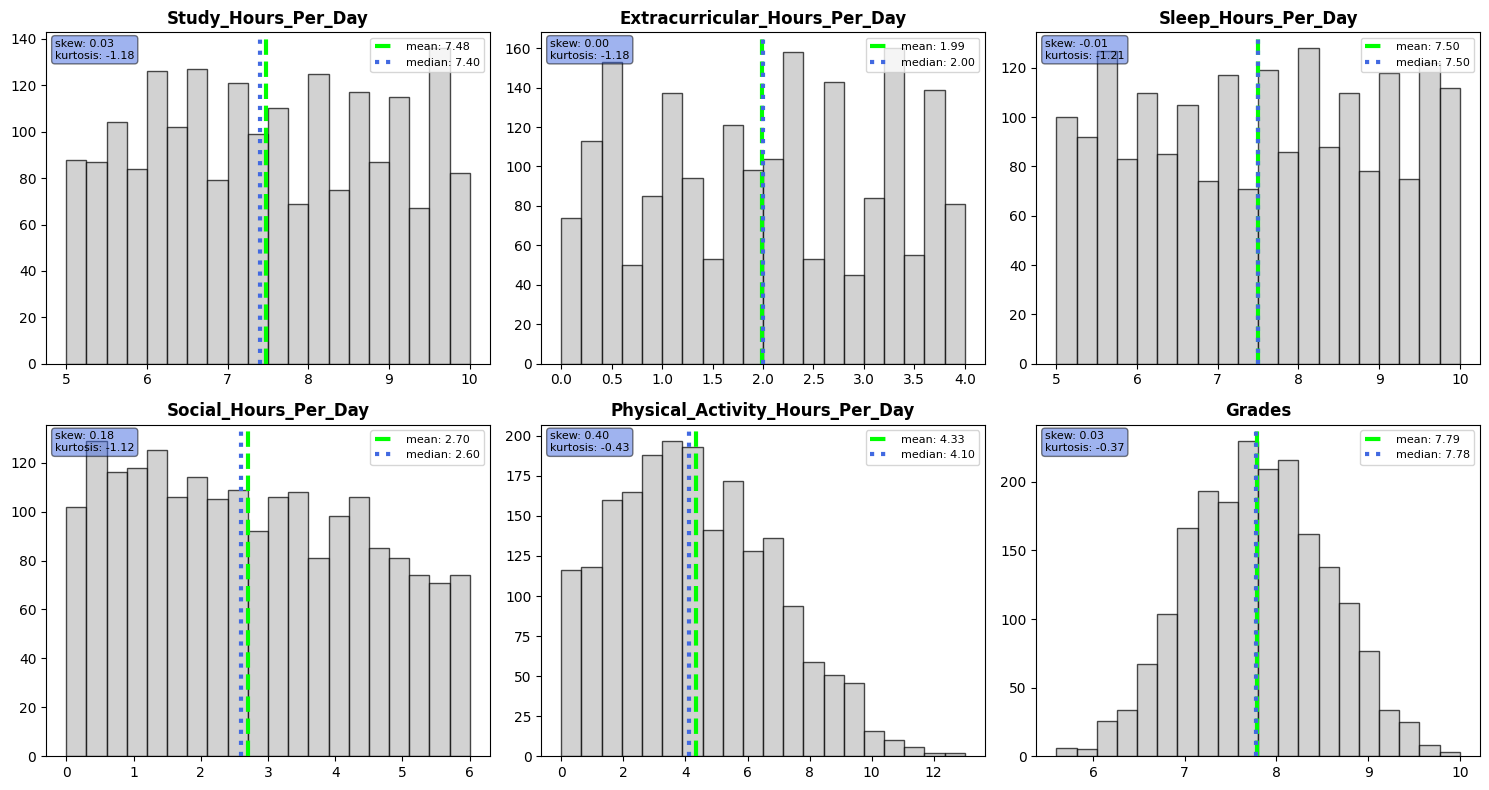

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes = axes.flatten()
for i, col in enumerate(metric_columns):
    ax = axes[i]
    
    data = df[col].dropna()
    ax.hist(data, bins=20, edgecolor='black', alpha=0.7, color='silver')
    
    ax.axvline(data.mean(), color='lime', linestyle='--', linewidth=3, label=f'mean: {data.mean():.2f}')
    ax.axvline(data.median(), color='royalblue', linestyle=':', linewidth=3, label=f'median: {data.median():.2f}')
    
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.grid(False)
    ax.legend(fontsize=8)
    
    stats_text = f'skew: {data.skew():.2f}\nkurtosis: {data.kurtosis():.2f}'
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=8, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='royalblue', alpha=0.5))

plt.tight_layout()
plt.show()

Еще можно построить ящики с усами, попутно оценив на предметр выбросов методом Межквартильного размаха

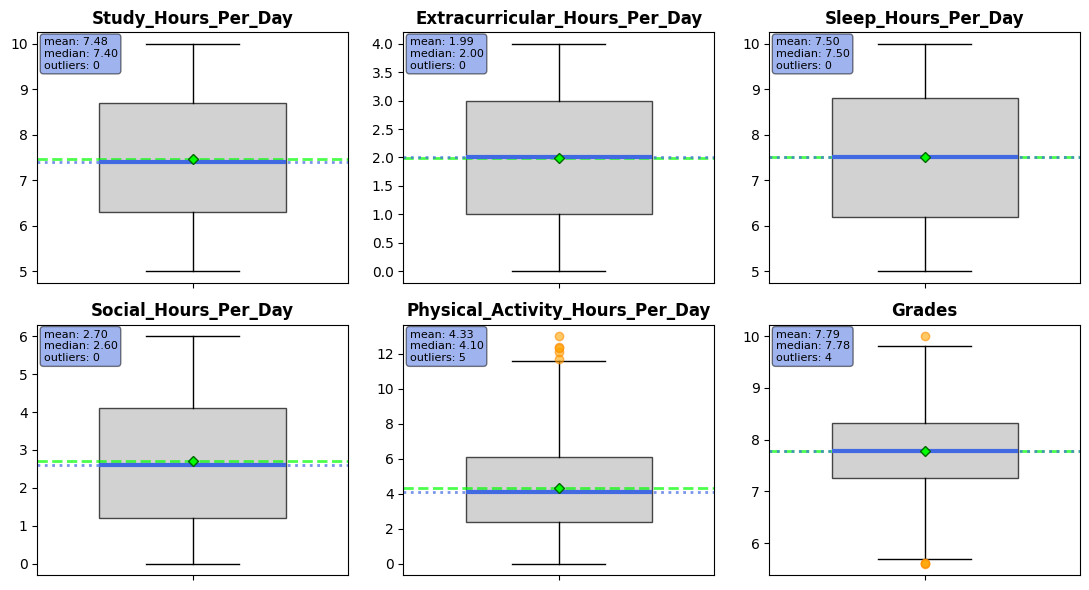

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(11, 6))
axes = axes.flatten()

for i, col in enumerate(metric_columns):
    ax = axes[i]
    
    data = df[col].dropna()
    
    box = ax.boxplot(data, vert=True, patch_artist=True, widths=0.6, showmeans=True)
    
    box['boxes'][0].set_facecolor('silver')
    box['boxes'][0].set_alpha(0.7)
    box['medians'][0].set_color('royalblue')
    box['medians'][0].set_linewidth(3)
    box['means'][0].set_marker('D')
    box['means'][0].set_markerfacecolor('lime')
    box['means'][0].set_markeredgecolor('darkgreen')
    box['means'][0].set_markersize(5)
    
    box['whiskers'][0].set_color('black')
    box['whiskers'][1].set_color('black')
    box['caps'][0].set_color('black')
    box['caps'][1].set_color('black')
    box['fliers'][0].set_marker('o')
    box['fliers'][0].set_markerfacecolor('orange')
    box['fliers'][0].set_markeredgecolor('darkorange')
    box['fliers'][0].set_alpha(0.6)
    
    ax.axhline(data.mean(), color='lime', linestyle='--', linewidth=2, alpha=0.7)
    ax.axhline(data.median(), color='royalblue', linestyle=':', linewidth=2, alpha=0.7)
    
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.grid(False)
    ax.set_xticks([1])
    ax.set_xticklabels([''])
    
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    outliers = data[(data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)]
    
    stats_text = (f'mean: {data.mean():.2f}\n'
                  f'median: {data.median():.2f}\n'
                  f'outliers: {len(outliers)}')
    
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=8, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='royalblue', alpha=0.5))

plt.tight_layout()
plt.show()

### Вывод

Были построены 2 вида графиков для неметрических атрибутов (`Stress_Level`, `Gender`) – столбчатая и круговая диграммы. А также 2 вида графиков для метрических атрибутов (`Study_Hours_Per_Day`, `Extracurricular_Hours_Per_Day`, `Sleep_Hours_Per_Day`, `Social_Hours_Per_Day`, `Physical_Activity_Hours_Per_Day`, `Grades`) – гистограммы и ящики с усами.